check basic statistical information over the dataset and try to learn specific info for your task to get helpful insights. Don't forget to remove/fill empty values and take steps to prevent data leak

prepare source texts and labels if needed, apply any data transformations you find suitable. Students working on multilabel classification task should define the labels they will learn to predict (minimum 5).


In [766]:
!pip install opendatasets


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [767]:
import opendatasets as od

od.download(
    "https://www.kaggle.com/datasets/maksimpotorochin/movie-plots-from-wikipedia-in-russian")

Skipping, found downloaded files in "./movie-plots-from-wikipedia-in-russian" (use force=True to force download)


In [768]:
import pandas as pd
df = pd.read_csv("films_data.csv")
df.head()

,title,type,genre,imdb_rating,summary,plot
0,? (фильм),film,драматический фильм,7.0,"«?» (индон. Tanda Tanya) — индонезийский художественный драматический фильм кинорежиссёра Хануна Брамантйо.\nВ главных ролях — Ревалина Темат, Реза Рахадиан, Агус Кунчоро, Эндхита, Рио Деванто и Хенки Сулаеман (индон. Hengky Sulaeman).\nГлавная тема — непростые межконфессиональные отношения в Индонезии, которые зачастую приводят к конфликтам между людьми с разными религиозными убеждениями. Главные герои фильма — члены трёх семей: буддистской, мусульманской и католической. Несколько из них погибнет в результате насилия на религиозной почве, но после многих несчастий эти семьи смогут примириться.\nВ основе сюжета лежит личный опыт Брамантйо, родители которого принадлежали к разным этническим группам. «?» был задуман в качестве противодействия изображению ислама как «радикальной религии». Тема религиозного плюрализма вызывает резкие противоречия в индонезийском обществе, и потому Брамантйо было трудно найти поддержку. Неожиданно компания «Mahaka Pictures» согласилась вложить в создание фильма 5 млрд индонезийских рупий. Съёмки начались 5 января 2011 года в Семаранге.\n7 апреля того же года фильм вышел на экраны, получил благоприятные отзывы кинокритиков и оказался коммерчески успешным: его посмотрели более 550 тысяч зрителей в Индонезии. Затем «?» был показан и в других странах. Фильм участвовал в девяти номинациях Индонезийского кинофестиваля, получил «Читру» (индон. Piala Citra, англ. Citra Award) в одной из них.\nТем не менее, ряд индонезийских мусульманских групп, включая «Индонезийский совет улемов», «Фронт защитников ислама» и «Нахдатул Улама», протестовали против фильма из-за того, что «?» пропагандировал ценности религиозного плюрализма.","Основная тема фильма — межрелигиозные отношения в Индонезии: стране, где конфликты на религиозной почве являются обычным делом, и долгое время продолжается дискриминация и насилие в отношении индонезийцев китайского происхождения.\nВ фильме показана судьба трёх семей, проживающих в деревне неподалёку от Семаранга (Центральная Ява): индонезиец китайского происхождения, буддист Тан Кат Сун (исполнитель роли — Хенки Сулаеман) и его сын Хендра (Рио Деванто); мусульманин Солех (Реза Рахадиан) и его жена, мусульманка Менук (Ревалина Темат); перешедшая из ислама в католицизм Рика (Эндхита) и её сын — мусульманин Аби.\nСун и Хендра владеют китайским рестораном, где подают, в том числе, блюда из свинины, запретной для мусульман; но при этом у ресторана есть много мусульманских клиентов и сотрудников. Чтобы поддерживать хорошие отношения со своими мусульманскими сотрудниками и клиентами, Сун использует для приготовления свинины отдельную посуду, которую он не разрешает использовать для других блюд. Сун разрешает сотрудникам совершать намазы в течение рабочего дня и отпускает их с работы во время Ураза-байрама, главного мусульманского праздника. У него работает и Менук, которая содержит своего безработного мужа Солеха. Рика дружит с Менук и встречается с мусульманином — актёром-неудачником Сурьей (Агус Кунчоро).\nВ возрасте более 70 лет Сун тяжело заболевает, и управление рестораном переходит к его сыну Хендре. Хендра не хочет иметь дело с мусульманами, а потому решает использовать свинину во всех мясных блюдах, подаваемых в ресторане. Также Хендра ссорится с Солехом из-за Менук, с которой Хендра ранее встречался. По той же причине Солех охладевает к Менук и говорит жене, что собирается развестись с ней. Менук от этого впадает во всё более сильную депрессию. Рика страдает из-за резко отрицательного отношения к ней её семьи и соседей, начавшегося после её перехода из ислама в католицизм; её сын Аби остался мусульманином, но тоже подвергается нападкам из-за матери. Между тем, Сурья и Дони (Гленн Фредли) увлекаются Рикой и борются друг с другом из-за неё. Сурья переживает из-за того, что не может найти хорошую актёрскую работу.\nВ дальнейшем Солех вступает в члены исламской благотворительной группы «Нахдатул Улама», 

In [769]:
!pip install kagglehub['hf-datasets']

zsh:1: no matches found: kagglehub[hf-datasets]


In [770]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45812 entries, 0 to 45811
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   title        45812 non-null  object 
 1   type         45812 non-null  object 
 2   genre        45000 non-null  object 
 3   imdb_rating  40195 non-null  float64
 4   summary      45812 non-null  object 
 5   plot         41955 non-null  object 
dtypes: float64(1), object(5)
memory usage: 2.1+ MB


In [771]:
# size
df.shape


(45812, 6)

Version 1: Movie genres identification (multilabel classification)
Target	"genre"
Source	"plot"

In [772]:
# number of classes and balance
df['genre'].value_counts()

genre
драма                                                       5234
комедия                                                     2788
мелодрама                                                    886
драматический фильм                                          661
фильм ужасов                                                 594
                                                            ... 
фильмограбление комедия криминал                               1
Криминальный триллер комедия фильмограбление приключения       1
гангстерский фильм комедия                                     1
документальный фильм и экологический фильмd                    1
комедия приключения мистика драма романтика                    1
Name: count, Length: 11025, dtype: int64

In [773]:
def avg_statistics(series: pd.Series):
    series_name = series.name
    awc = series.str.split().str.len().mean()
    asl = series.str.len().mean()
    awl = (asl - awc + 1) / awc

    return (
        (f'average words count in {series_name}', awc),
        (f'average symbols count in {series_name}', asl),
        (f'average words length in {series_name}', awl)
    )

In [774]:
avg_statistics(df['genre'])

(('average words count in genre', np.float64(2.2492444444444444)),
 ('average symbols count in genre', np.float64(18.60331111111111)),
 ('average words length in genre', np.float64(7.71550940562757)))

In [775]:
avg_statistics(df['plot'])


(('average words count in plot', np.float64(209.34267667739243)),
 ('average symbols count in plot', np.float64(1434.103515671553)),
 ('average words length in plot', np.float64(5.855284065575982)))

In [776]:
pd.set_option('display.max_colwidth', None)
df.sample(1, random_state = 5)

title  type        genre  imdb_rating  \
13411  Крид 2  film  спорт драма          7.1   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                           summary  \
13411  Запросы «Рокки 8» и «Рокки VIII» перенаправляются сюда.\n«Крид 2» (англ. Creed II) — американский спортивный драматический фильм с Майклом Б. Джорданом и Сильвестром Сталлоне в главных ролях, являющийся восьмым по счёту во франшизе «Рокки» и вторым в её побочной серии. Сюжет продолжает историю фильмов «Крид: Наследие Рокки» и «Рокки 4», возвращая на экраны таких персонажей, как Иван Драго, Людмила Драго и Роберт Бальбоа в исполнении Дольфа Лундгрена, Бригитты Нильсен и Майло Вентимильи соответственно. Также в картине снялись Тесса Томпсон, Флориан Мунтяну, Филисия Рашад и другие актёры.\nАвторами сценария, написанного по сюжету Саши Пенна и Чео Ходари Кокера, выступили Юэль Тейлор и Сильвестр Сталлоне, который до этого в одиночку написал сценарии шести первых фильмов, а также участвовал в доработке и корректировке сценария седьмой ленты. На должность постановщика, как и в седьмом фильме, было решено пригласить начинающего кинодеятеля, которым на этот раз стал Стивен Кейпл-младший — режиссёр драмы «Земля обетованная», являвшейся его первой и единственной тогда полнометражной работой. Кейпл-младший был назначен на свою должность в связи с уходом Райана Куглера — режиссёра и основного сценариста предыдущей ленты, который из-за занятости в фильме «Чёрная пантера» смог принять участие лишь в качестве исполнительного продюсера вместе с Майклом Б. Джорданом.\nВыход фильма в кинотеатральный прокат в США состоялся 21 ноября 2018 года, а в России — 10 января 2019 года.   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                        

In [777]:
df.isnull().sum()

title             0
type              0
genre           812
imdb_rating    5617
summary           0
plot           3857
dtype: int64

In [778]:
df = df[(df['genre'].notna()) & (df['plot'].notna()) &
        (df['genre'] != '') & (df['plot'] != '')]


In [779]:
df.isnull().sum()

title             0
type              0
genre             0
imdb_rating    4649
summary           0
plot              0
dtype: int64

In [780]:
print(df['plot'].duplicated().sum())

1562


In [781]:
df_plot_words_count = df['plot'].str.split().str.len()

In [782]:
df_plot_words_count.describe()

count    41332.000000
mean       210.474596
std        270.794094
min          4.000000
25%         60.000000
50%        107.000000
75%        242.000000
max       4130.000000
Name: plot, dtype: float64

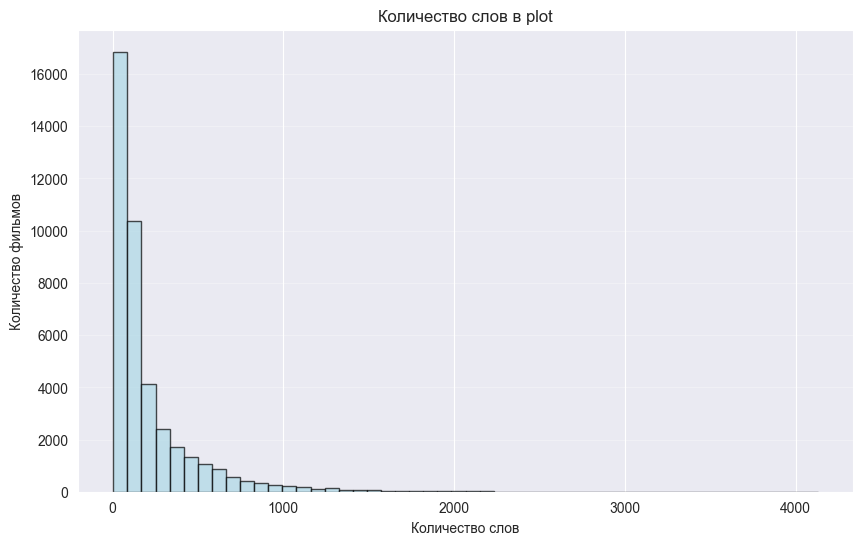

In [783]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(df_plot_words_count, bins=50, alpha=0.7, color='lightblue', edgecolor='black')
plt.title('Количество слов в plot')
plt.xlabel('Количество слов')
plt.ylabel('Количество фильмов')
plt.grid(axis='y', alpha=0.3)
plt.show()

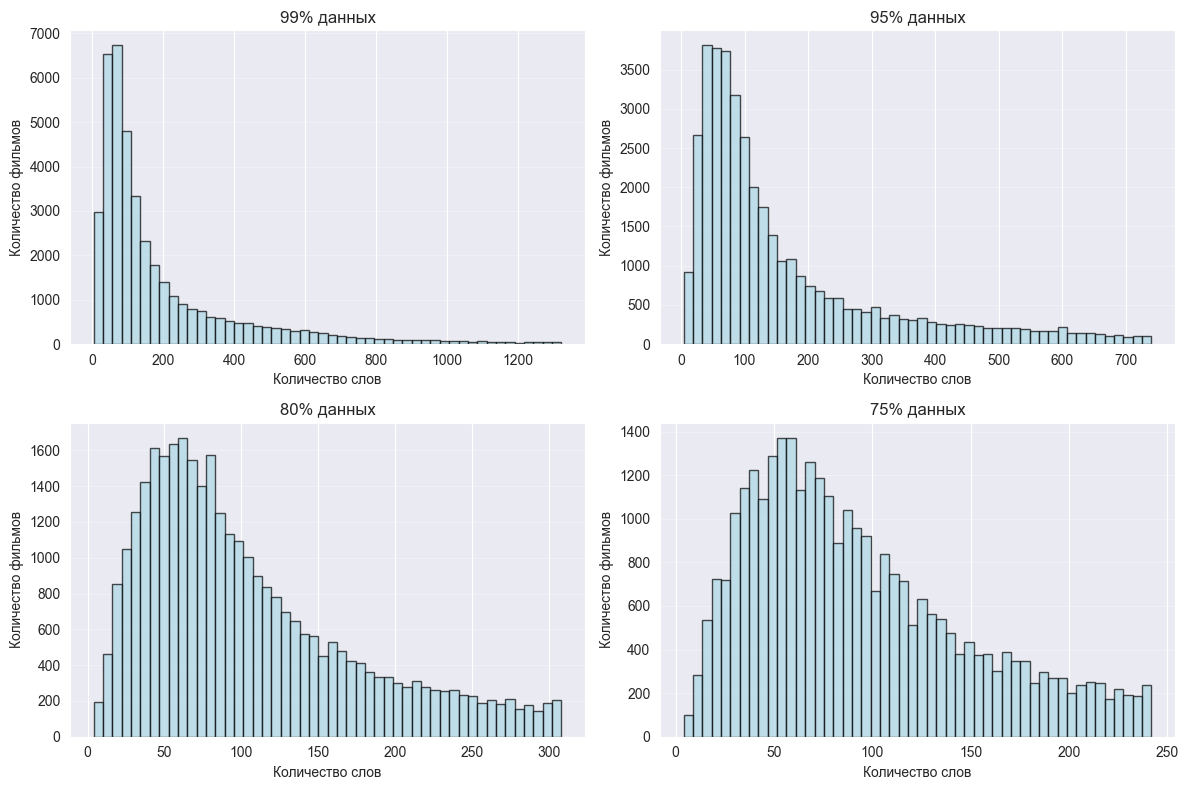

In [784]:
import numpy as np
import matplotlib.pyplot as plt

percentiles = [99, 95, 80, 75]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for i, percentile in enumerate(percentiles):
    percentile_value = np.percentile(df_plot_words_count, percentile)

    axes.flat[i].hist(df_plot_words_count[df_plot_words_count <= percentile_value],
                 bins=50, alpha=0.7, color='lightblue', edgecolor='black')
    axes.flat[i].set_title(f'{percentile}% данных')
    axes.flat[i].set_xlabel('Количество слов')
    axes.flat[i].set_ylabel('Количество фильмов')
    axes.flat[i].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [785]:
df_genre_words_count = df['genre'].str.split().str.len()

In [786]:
df_genre_words_count.describe()

count    41332.000000
mean         2.246081
std          1.462227
min          1.000000
25%          1.000000
50%          2.000000
75%          3.000000
max         40.000000
Name: genre, dtype: float64

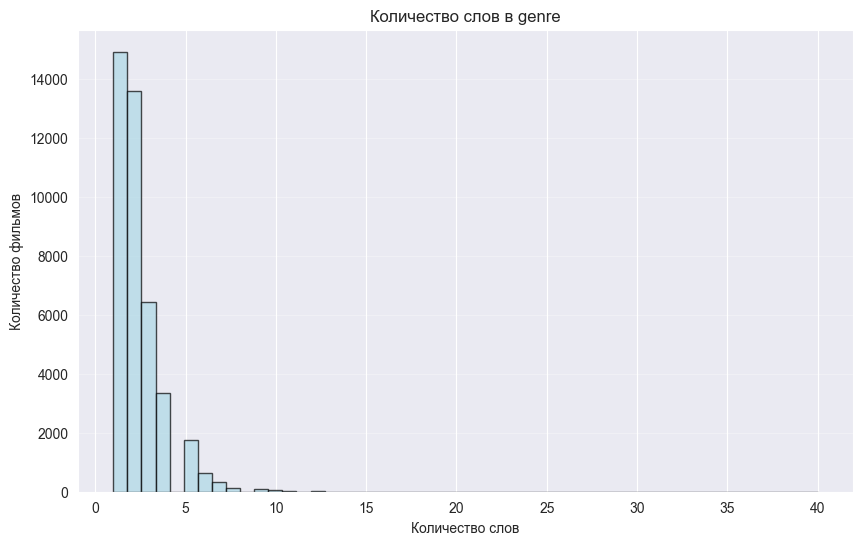

In [787]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(df_genre_words_count, bins=50, alpha=0.7, color='lightblue', edgecolor='black')
plt.title('Количество слов в genre')
plt.xlabel('Количество слов')
plt.ylabel('Количество фильмов')
plt.grid(axis='y', alpha=0.3)
plt.show()

In [788]:
# Топ-10 жанров по количеству слов
top_genres = df['genre'].apply(lambda x: len(str(x).split())).sort_values(ascending=False).head(50)

print("Топ-50 жанров:")
for count, genre in zip(top_genres.values, df.loc[top_genres.index, 'genre']):
    print(f"{count}: {genre}")

Топ-50 жанров:
40: подростковая ситуационная комедия ситком комедийный телесериалd фэнтезийный телесериалd мультфильм с живыми актёрами музыкальный фильм семейный телесериалd история взросления фэнтезийная телевизионная программаd фэнтези мюзикл музыкальная комедияd музыкальное телевиденьеd ситком СШАd приключенческий телесериал подростковая драма драматический сериал family dramad и комедийная драма
24: эпическая драма история взросления экзистенциальная притчаmwparseroutput tsfixtemplatewhitespacenowrapmwparseroutput tsfixerrorfontsizeinheritmedia screenmwparseroutput tsfixtextborderpx solid aabboxdecorationbreakclonemargin empadding emtransitionbackground smwparseroutput hover tsfixtextbackgroundfeeemedia screen and hoverhovermwparseroutput tsfixcommentmwparseroutput tsfixcommentedanothoverborderbottompx dottedtextdecorationnoneнеавторитетный источник
21: Ужасы Фантастика Боевикmwparseroutput tsfixtemplatewhitespacenowrapmwparseroutput tsfixerrorfontsizeinheritmedia screenmwparserou

1. убрать фильм
2. оставить корни
3. убрать английские буквы
4. после этого в рамках каждого жанра убрать повторяющиеся слова


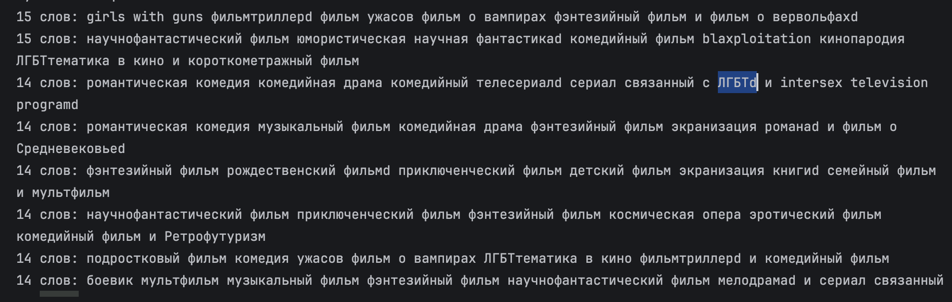

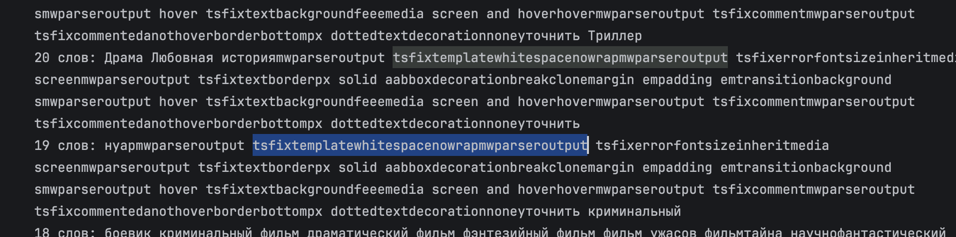

tsfixtemplatewhitespacenowrapmwparseroutput

In [789]:
from collections import Counter

all_words = []
for text in df['genre']:
        all_words.extend(text.split())

word_freq = Counter(all_words)

freq_df = pd.DataFrame(word_freq.items(), columns=['word', 'frequency'])
freq_df = freq_df.sort_values('frequency', ascending=False).reset_index(drop=True)

print(freq_df.head(20))

               word  frequency
0             драма      14797
1             фильм       9494
2           комедия       8728
3           триллер       3709
4            боевик       3525
5         мелодрама       3348
6        фантастика       2632
7       приключения       2312
8            ужасов       1728
9           фэнтези       1556
10                и       1407
11    драматический       1388
12         детектив       1265
13  приключенческий       1097
14         семейный       1055
15     исторический       1047
16          военный       1032
17     криминальный        828
18           сказка        823
19          научная        815


In [790]:
from nltk.stem.snowball import SnowballStemmer

stemmer = SnowballStemmer("russian")

stop_words = {
    'в', 'во', 'на', 'над', 'под', 'к', 'у', 'о', 'об', 'от', 'до', 'по',
    'за', 'с', 'со', 'из', 'или', 'и', 'но', 'а', 'да', 'же', 'ли', 'бы',
    'б', 'то', 'либо', 'ни', 'не', 'нибудь', 'как', 'так', 'что', 'чтоб',
    'чтобы', 'это', 'вот', 'вон', 'тут', 'там', 'тогда', 'потом', 'опять',
    'уж', 'ужо', 'ведь', 'мол', 'дескать', 'тоже', 'только', 'лишь', 'хоть',
    'хотя', 'словно', 'будто', 'кабы', 'коли', 'ежели'
}

def process_genres(genre_text):
    cleaned_text = re.sub(r'[^а-яё0-9\s]', ' ', str(genre_text).lower())
    cleaned_text = re.sub(r'\s+', ' ', cleaned_text).strip()
    words = cleaned_text.split()

    stem_words = [stemmer.stem(word) for word in words if word not in stop_words]

    filtered_words = []
    for word in stem_words:
        if not ('фильм' or 'сериа' or 'телесериа' or 'ситк' or 'кин' or 'и') in word:
            filtered_words.append(word)

    seen = set()
    unique_words = []
    for word in filtered_words:
        if word not in seen:
            seen.add(word)
            unique_words.append(word)

    return ' '.join(unique_words)

df['genre_proc'] = df['genre'].apply(process_genres)

In [791]:
# Топ-10 жанров по количеству слов
top_genres = df['genre_proc'].apply(lambda x: len(str(x).split())).sort_values(ascending=False).head(50)

print("Топ-50 жанров:")
for count, genre in zip(top_genres.values, df.loc[top_genres.index, 'genre_proc']):
    print(f"{count}: {genre}")

Топ-50 жанров:
23: подростков ситуацион комед ситк комедийн телесериа фэнтезийн жив актер музыкальн семейн истор взрослен телевизион программ фэнтез мюзикл телевиден сша приключенческ драм драматическ сериа
11: супергеройск боевик приключен криминальн драм детект психологическ триллер научн фантастик неонуар
11: комед приключен технофэнтез постапокалиптик сюрреализм абсурд психолог мелодрам экспериментальн кин драм
10: парод боевик приключен фэнтез комед научн фантастик романтик гар этт
10: супергеройск боевик приключен криминальн драм юридическ научн фантастик триллер неонуар
10: анимац приключен фэнтез комед драм семейн научн фантастик мюзикл экшн
10: супергеройск боевик приключен необлексплоитейшн криминальн драм научн фантастик триллер неонуар
10: парод боевик приключен фэнтез комед научн фантастик романтик гар этт
10: подростков истор взрослен комедийн драм драматическ романтическ комед американск футбол
9: комед ситк подростков ситуацион хипхопкультур черн юмор афроситк сем
9: на

In [792]:
from collections import Counter

all_words = []
for text in df['genre_proc']:
        all_words.extend(text.split())

word_freq = Counter(all_words)

freq_df = pd.DataFrame(word_freq.items(), columns=['word', 'frequency'])
freq_df = freq_df.sort_values('frequency', ascending=False).reset_index(drop=True)

print(freq_df.head(50))

                  word  frequency
0                 драм      15422
1                комед       9202
2              триллер       3946
3               боевик       3687
4             мелодрам       3655
5            фантастик       2770
6                 ужас       2650
7            приключен       2563
8               фэнтез       1640
9           историческ       1464
10              детект       1419
11         драматическ       1400
12                воен       1308
13          криминальн       1275
14              семейн       1204
15       приключенческ       1188
16               научн        912
17               сказк        890
18         романтическ        880
19            комедийн        871
20           музыкальн        863
21           экранизац        788
22        документальн        711
23                нуар        578
24             кримина        476
25              мистик        473
26              мюзикл        454
27           кинокомед        436
28            

In [793]:
print(freq_df.tail(20))

                        word  frequency
896              драмасемейн          1
897                секскомед          1
898                 семингэк          1
899               андеграунд          1
900                    лубок          1
901       военнопатриотическ          1
902                    токшо          1
903   производственноколхозн          1
904               фолкхистор          1
905  хроникальнодокументальн          1
906                киноочерк          1
907       историкобиографичн          1
908  революционноромантическ          1
909                    район          1
910                       йн          1
911                        м          1
912                сатрическ          1
913               телеповест          1
914    социальнопедагогическ          1
915               седзедзесэ          1


нам надо учиться предсказывать минимум 5 лейблов - столько и оставим. возьмем наиболее частотные и разнообразные лейблы, так как в задании нет на это ограничений, к тому же разнообразные - понятие субьективное

1. 0                 драм      15422
2. 1                комед       9202
3. 2              триллер       3946
4. 3               боевик       3687
5. 4            фантастик       2770

часто драма является сопуствующим жанром к остальным( драма + комедия\триллер\боевик) и тд, поэтому возьмем те жанры, которые субьективно имеют меньше пересечений друг с другом ( с научной точки зрения выберем случайные пять жанров)

* комедия
* триллер
* боевик
* фантастика
* детект

In [794]:
des_genres = ['комед', 'триллер', 'боевик', 'фантастик', 'детект']

def contains_desired_genres(genre_text):
    if not genre_text or genre_text.strip() == '':
        return False

    words = set(genre_text.split())
    return any(genre in words for genre in des_genres)

df_filtered = df[df['genre_proc'].apply(contains_desired_genres)]
df = df_filtered.copy()

In [795]:
def keep_only_desired_genres(genre_text):
    if not genre_text or genre_text.strip() == '':
        return ''

    words = genre_text.split()
    filtered_words = [word for word in words if word in des_genres]

    seen = set()
    unique_words = []
    for word in filtered_words:
        if word not in seen:
            seen.add(word)
            unique_words.append(word)

    return ' '.join(unique_words)

df['genre_proc'] = df['genre_proc'].apply(keep_only_desired_genres)

print("Примеры после очистки:")
print(df['genre_proc'].head(10))

all_words = []
for text in df['genre_proc']:
    all_words.extend(text.split())

word_freq = Counter(all_words)
freq_df = pd.DataFrame(word_freq.items(), columns=['word', 'frequency'])
freq_df = freq_df.sort_values('frequency', ascending=False).reset_index(drop=True)

print("\nЧастотность оставшихся жанров:")
print(freq_df)

Примеры после очистки:
4     комед фантастик
5               комед
10              комед
13              комед
14              комед
15              комед
18            триллер
21             боевик
22              комед
27             боевик
Name: genre_proc, dtype: object

Частотность оставшихся жанров:
        word  frequency
0      комед       9202
1    триллер       3946
2     боевик       3687
3  фантастик       2770
4     детект       1419


In [796]:
df = df[df['genre_proc'].apply(lambda x: len(x.split()) == 1)]

print(f"Размер датасета после оставления только одного жанра: {len(df)} записей")

genres_count = {}
for genre in des_genres:
    count = df[df['genre_proc'] == genre].shape[0]
    genres_count[genre] = count

print("\nИтоговое распределение по жанрам:")
for genre, count in sorted(genres_count.items(), key=lambda x: x[1], reverse=True):
    percentage = count/len(df)*100 if len(df) > 0 else 0
    print(f"{genre}: {count} записей ({percentage:.1f}%)")

Размер датасета после оставления только одного жанра: 14737 записей

Итоговое распределение по жанрам:
комед: 7884 записей (53.5%)
триллер: 2520 записей (17.1%)
боевик: 2027 записей (13.8%)
фантастик: 1514 записей (10.3%)
детект: 792 записей (5.4%)


в реальном мире комедий больше всех остальных, и мы еще не удаляли строки где слишком короткий или длинный плот, поэтому оставим не больше 1000 записей для каждого класса


In [797]:
df.head(1)

,title,type,genre,imdb_rating,summary,plot,genre_proc
5,0-41*,film,документальный драма комедия,8.9,"«0-41*» — индийский документальный драматический фильм 2016 года режиссёра Сенна Хегде, в котором исследуется жизнь группы молодых людей в сельской местности, играющих в волейбол.\nМировая премьера состоялась 26 января 2016 года на 11 кинофестивале в Баю в Лафайетте (Bayou Film Festival), штат Луизиана, США. Премьера в ЮАР прошла 14 марта 2016 года. В Индии зрители увидели фильм 15 августа 2016 года.\nСлоган фильма звучит как «Let Your Faith Be Bigger Than Your Fear» — «Пусть ваша вера будет больше вашего страха».","Действие фильма происходит в небольшом городе Канхангад (Северная Керала). Фильм рассказывает реальные истории различных людей, которые переосмысливают события, произошедшие с ними. Показаны их жизненные истории, чаяния и ожидания, вера и страхи, а также взгляды на остальной мир, а сельский образ жизни Индии представляет собой яркий фон. Действие фильма разворачивается в течение шести дней.\nГруппа местной молодежи в небольшом городке в Индии каждый вечер дружно играет в волейбол. Раджеш и Випин с огромным энтузиазмом возглавляют свои волейбольные команды, пока, казалось бы, бесконечная полоса поражений не приводит Раджеша и его команду к унынию и потере веры в себя. В документальной драме проводится тонкая параллель между полосой неудач и умением взять свою жизнь под контроль.",комед


In [798]:
df_ = df[['plot', 'genre_proc']]
df_ = df_.rename(columns={'genre_proc': 'genre'})

In [799]:
df_.head()

,plot,genre
5,"Действие фильма происходит в небольшом городе Канхангад (Северная Керала). Фильм рассказывает реальные истории различных людей, которые переосмысливают события, произошедшие с ними. Показаны их жизненные истории, чаяния и ожидания, вера и страхи, а также взгляды на остальной мир, а сельский образ жизни Индии представляет собой яркий фон. Действие фильма разворачивается в течение шести дней.\nГруппа местной молодежи в небольшом городке в Индии каждый вечер дружно играет в волейбол. Раджеш и Випин с огромным энтузиазмом возглавляют свои волейбольные команды, пока, казалось бы, бесконечная полоса поражений не приводит Раджеша и его команду к унынию и потере веры в себя. В документальной драме проводится тонкая параллель между полосой неудач и умением взять свою жизнь под контроль.",комед
10,"Колхозники-виноградари отправляют для тестирования местному учёному-виноделу Погосу Погосяну бочонок коньяка. Проблема в том, что это ответственное дело было поручено Гарсевану, неравнодушного к коньяку, и по пути помаленьку пробуя порученный ему груз он напивается до безчувствия и падает на обочине. Проезжающая мимо молодая пара думает, что лежащий на обочине мужчина стал жертвой ДТП. Гарсвеан не может связать и двух слов, но бормочет «01-99», и молодые люди решают, что это госномер сбившей его машины (на самом деле это номер телефона учёного). Молодые люди обращаются в отделение милиции. Начинается неразбериха: Погоса путают с Петросом, бочонок уходит не в те руки, родственники водителя машины с действительно существующим номером 01-99 узнают о «случившемся» и бегут «извиняться» перед Гарсеваном. Недоразумения удаётся разрешить только в финале фильма, хотя сам Гарсеван так до конца и не понимает что же произошло и произошло ли вообще.",комед
13,"Марион и Джек пытаются возродить свои отношения, посетив Париж — дом родителей Марион и нескольких её бывших бойфрендов.",комед
14,"Собственно фр. cloche означает колокол, как, например, в композиции «Cloches sous la neige» («Колокола под снегом») композитора Марселя Турнье. Однако в разговорном французском это также значит дурень, недотёпа, о паре которых и идёт речь в фильме.\nДва жизнерадостных друга (в ролях Кристиан Марен и Бубуль), не слишком одарённые умом, но удачливые в жизненных ситуациях, попадают на примету двум международным гангстерам (в ролях Анри Царняк и Жан-Луи Гийерму), планирующих ввести из Франции в Италию и Швейцарию грузы героина по маршруту через Альпы на стыке трёх стран.\nВ череде событий «2 дурня» оказываются на чужой машине с грузом героина в Анси, где срывают банк в казино, вместе с преследующими их гангстерами вынуждены принять участие в чемпионате по фристайлу и испытать много иных приключений.",комед
15,"Лори вынуждена уйти из маунтин-байка, которым она профессионально занималась, потому что на старте она задержалась на целых две секунды. Директор команды увольняет её, и Лори возвращается в Монреаль, в свой родной город, где останавливается у брата. Потерянная, она находит отдушину, когда устраивается на работу велосипедным курьером. Теперь она снова может целые дни проводить на велосипеде. Однажды она знакомится с Лоренцо — владельцем велосипедного магазина. Они находят друг в друге родственные души. История о том, как однажды Лоренцо, бывший профессиональный гонщик, упустил своё счастье, производит впечатление на Лори. Она понимает, что и в её жизни, в которой нет ничего, кроме велосипеда, может появиться любимый человек.",комед


In [800]:
df_ = df_[df_['plot'].str.split().str.len().between(60, 250)]

print("\nРаспределение по жанрам после фильтрации:")
genre_counts = df_['genre'].value_counts()
for genre, count in genre_counts.items():
    print(f"{genre}: {count} записей ({count/len(df_)*100:.1f}%)")


Распределение по жанрам после фильтрации:
комед: 4264 записей (56.8%)
триллер: 1095 записей (14.6%)
боевик: 927 записей (12.4%)
фантастик: 808 записей (10.8%)
детект: 410 записей (5.5%)


In [801]:
balanced_dfs = []

n_samples_per_genre = 1000

for genre in df_['genre'].unique():
    genre_df = df_[df_['genre'] == genre]

    if len(genre_df) > n_samples_per_genre:
        genre_df = genre_df.sample(n=n_samples_per_genre, random_state=42)

    balanced_dfs.append(genre_df)

df_balanced = pd.concat(balanced_dfs, ignore_index=True)

print(f"Размер сбалансированного датасета: {len(df_balanced)} записей")
print("\nРаспределение по жанрам после балансировки:")
genre_counts = df_balanced['genre'].value_counts()
for genre, count in genre_counts.items():
    print(f"{genre}: {count} записей ({count/len(df_balanced)*100:.1f}%)")

df_ = df_balanced.copy()

Размер сбалансированного датасета: 7504 записей

Распределение по жанрам после балансировки:
комед: 4264 записей (56.8%)
триллер: 1095 записей (14.6%)
боевик: 927 записей (12.4%)
фантастик: 808 записей (10.8%)
детект: 410 записей (5.5%)


In [802]:
import nltk
from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer
import ssl


try:
    _create_unverified_https_context = ssl._create_unverified_context
except AttributeError:
    pass
else:
    ssl._create_default_https_context = _create_unverified_https_context

try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    nltk.download('punkt')
try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords')

stemmer = SnowballStemmer("russian")

russian_stopwords = set(stopwords.words('russian'))

def preprocess_plot(text):

    text = text.lower()

    text = re.sub(r'[^а-яё\s\-\.\,\!\?]', ' ', text)

    text = re.sub(r'\s+', ' ', text).strip()

    tokens = text.split()

    filtered_tokens = [word for word in tokens if word not in russian_stopwords and len(word) > 2]

    stemmed_tokens = [stemmer.stem(word) for word in filtered_tokens]
    preprocessed_text = ' '.join(stemmed_tokens)

    return preprocessed_text
df_['plot_preprocessed'] = df_['plot'].apply(preprocess_plot)

In [803]:
df_.head(1)

,plot,genre,plot_preprocessed
0,"Действие фильма происходит в небольшом городе Канхангад (Северная Керала). Фильм рассказывает реальные истории различных людей, которые переосмысливают события, произошедшие с ними. Показаны их жизненные истории, чаяния и ожидания, вера и страхи, а также взгляды на остальной мир, а сельский образ жизни Индии представляет собой яркий фон. Действие фильма разворачивается в течение шести дней.\nГруппа местной молодежи в небольшом городке в Индии каждый вечер дружно играет в волейбол. Раджеш и Випин с огромным энтузиазмом возглавляют свои волейбольные команды, пока, казалось бы, бесконечная полоса поражений не приводит Раджеша и его команду к унынию и потере веры в себя. В документальной драме проводится тонкая параллель между полосой неудач и умением взять свою жизнь под контроль.",комед,"действ фильм происход небольш город канхангад северн кера фильм рассказыва реальн истор различн людей, котор переосмыслива события, произошедш ними. показа жизнен истории, чаян ожидания, вер страхи, такж взгляд остальн мир, сельск образ жизн инд представля соб ярк фон. действ фильм разворачива течен шест дней. групп местн молодеж небольш городк инд кажд вечер дружн игра волейбол. раджеш випин огромн энтузиазм возглавля сво волейбольн команды, пока, каза бы, бесконечн полос поражен привод раджеш команд унын потер вер себя. документальн драм провод тонк параллел полос неудач умен взят жизн контроль."


in order to work with RNN you must first prepare a dictionary and convert each text into list of indexes.

In [804]:
import re
from collections import Counter
from sklearn.model_selection import train_test_split
from tqdm import tqdm

train_df, temp_df = train_test_split(df_, test_size=0.2, random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42)

def tokenize(text):
    return re.findall(r'\w+|[^\w\s]', text)

def build_vocab(train_dataframe, max_features):
    words_counts = Counter()
    for text in tqdm(train_dataframe['plot_preprocessed']):
        words_counts.update(tokenize(text))

    most_common = words_counts.most_common(max_features)
    vocab = {word: i for i, (word, _) in enumerate(most_common, start=2)}
    vocab['<PAD>'] = 0
    vocab['<UNK>'] = 1
    return vocab

vocab = build_vocab(train_df, 18000)
vocab_size = len(vocab)

def text_to_indices(text):
    tokens = tokenize(text)
    indices = []
    for token in tokens:
        indices.append(vocab.get(token, vocab['<UNK>']))
    return indices

train_df['indices'] = train_df['plot_preprocessed'].apply(text_to_indices)
val_df['indices'] = val_df['plot_preprocessed'].apply(text_to_indices)
test_df['indices'] = test_df['plot_preprocessed'].apply(text_to_indices)

100%|██████████| 6003/6003 [00:00<00:00, 59994.15it/s]


In [805]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df_['genre_encoded'] = le.fit_transform(df_['genre'])

train_df['genre_encoded'] = df_.loc[train_df.index, 'genre_encoded']
val_df['genre_encoded'] = df_.loc[val_df.index, 'genre_encoded']
test_df['genre_encoded'] = df_.loc[test_df.index, 'genre_encoded']

In [806]:
train_df['genre'].head()

4921    боевик
4591    боевик
3647     комед
2948     комед
2513     комед
Name: genre, dtype: object

In [807]:
from torch.utils.data import Dataset, DataLoader

class CustomDataset(Dataset):
    def __init__(self, indices_list, labels, max_len):
        self.indices_list = indices_list.values
        self.labels = labels.values
        self.max_len = max_len

    def __len__(self):
        return len(self.indices_list)

    def __getitem__(self, idx):
        indexed = self.indices_list[idx].copy()

        if len(indexed) < self.max_len:
            indexed += [0] * (self.max_len - len(indexed))
        else:
            indexed = indexed[:self.max_len]

        return torch.tensor(indexed), torch.tensor(self.labels[idx], dtype=torch.long)

MAX_LEN = 250

train_ds = CustomDataset(train_df['indices'], train_df['genre_encoded'], MAX_LEN)
val_ds = CustomDataset(val_df['indices'], val_df['genre_encoded'], MAX_LEN)
test_ds = CustomDataset(test_df['indices'], test_df['genre_encoded'], MAX_LEN)

train_loader = DataLoader(train_ds, batch_size=128, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=128, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=128, shuffle=False)

use any word-level vectorization technique, explain your choice.

Baseline Model Results (Logistic Regression):
Accuracy: 0.7244
F1-score (micro): 0.7244

Classification Report:
              precision    recall  f1-score   support

      боевик       0.82      0.49      0.61        96
      детект       0.62      0.26      0.36        39
       комед       0.72      0.97      0.83       426
     триллер       0.59      0.32      0.41       116
   фантастик       0.83      0.51      0.63        74

    accuracy                           0.72       751
   macro avg       0.72      0.51      0.57       751
weighted avg       0.72      0.72      0.69       751

Epoch 01 | Train Loss: 1.3662 | Val Loss: 1.2390
Epoch 02 | Train Loss: 1.2543 | Val Loss: 1.2299
Epoch 03 | Train Loss: 1.2296 | Val Loss: 1.2149
Epoch 04 | Train Loss: 1.2036 | Val Loss: 1.2074
Epoch 05 | Train Loss: 1.1821 | Val Loss: 1.1916
Epoch 06 | Train Loss: 1.1551 | Val Loss: 1.1719
Epoch 07 | Train Loss: 1.1166 | Val Loss: 1.1666
Epoch 08 | Train Loss: 1.0599 | Val Loss: 1.1387
Epoch 0

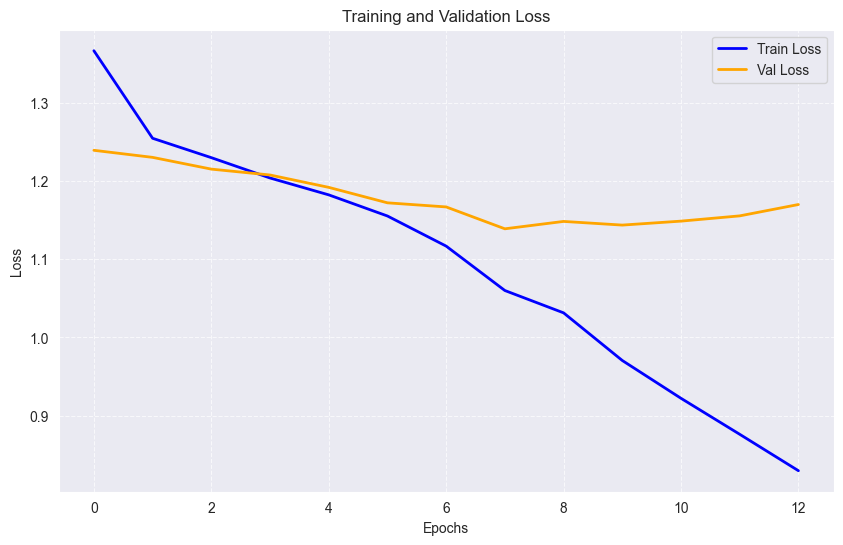

Accuracy: 0.6018641810918774
F1-score (micro): 0.6018641810918774
F1-score (macro): 0.3421932542407656

Classification Report:
              precision    recall  f1-score   support

      боевик       0.27      0.21      0.24        96
      детект       0.67      0.05      0.10        39
       комед       0.66      0.91      0.77       426
     триллер       0.41      0.11      0.18       116
   фантастик       0.52      0.38      0.44        74

    accuracy                           0.60       751
   macro avg       0.50      0.33      0.34       751
weighted avg       0.56      0.60      0.54       751



In [808]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import numpy as np

from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, accuracy_score, f1_score

tfidf = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf.fit_transform(train_df['plot_preprocessed'])
X_test_tfidf = tfidf.transform(test_df['plot_preprocessed'])

le_baseline = LabelEncoder()
y_train_encoded = le_baseline.fit_transform(train_df['genre'])
y_test_encoded = le_baseline.transform(test_df['genre'])

baseline_model = LogisticRegression(max_iter=1000, random_state=42)
baseline_model.fit(X_train_tfidf, y_train_encoded)
baseline_preds = baseline_model.predict(X_test_tfidf)

print("Baseline Model Results (Logistic Regression):")
print(f"Accuracy: {accuracy_score(y_test_encoded, baseline_preds):.4f}")
print(f"F1-score (micro): {f1_score(y_test_encoded, baseline_preds, average='micro'):.4f}")
print("\nClassification Report:")
print(classification_report(y_test_encoded, baseline_preds, target_names=le_baseline.classes_))


class RNNModel(nn.Module):
    def __init__(self, vocab_size, emb_dim, hidden_dim, num_classes):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=0)

        self.rnn = nn.RNN(emb_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(hidden_dim * 2, num_classes)
        )

    def forward(self, x):
        emb = self.embedding(x)
        _, hidden = self.rnn(emb)
        if self.rnn.bidirectional:
            hidden = torch.cat((hidden[-2], hidden[-1]), dim=1)
        else:
            hidden = hidden[-1]
        return self.classifier(hidden)


num_classes = len(des_genres)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = RNNModel(vocab_size=vocab_size, emb_dim=128, hidden_dim=64, num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
epochs = 30
patience = 5
best_val_loss = float('inf')
early_stop_counter = 0
best_model_state = None

history = {'train_loss': [], 'val_loss': []}

for epoch in range(epochs):
    model.train()
    train_loss_accum = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss_accum += loss.item()

    avg_train_loss = train_loss_accum / len(train_loader)

    model.eval()
    val_loss_accum = 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss_accum += loss.item()

    avg_val_loss = val_loss_accum / len(val_loader)

    history['train_loss'].append(avg_train_loss)
    history['val_loss'].append(avg_val_loss)

    print(f"Epoch {epoch + 1:02d} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_model_state = model.state_dict().copy()
        early_stop_counter = 0
    else:
        early_stop_counter += 1
        if early_stop_counter >= patience:
            print(f"Early stopping triggered at epoch {epoch + 1}")
            break

if best_model_state:
    model.load_state_dict(best_model_state)
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(history['train_loss'], label='Train Loss', color='blue', lw=2)
plt.plot(history['val_loss'], label='Val Loss', color='orange', lw=2)
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()
from sklearn.metrics import classification_report, accuracy_score, f1_score


def evaluate_model(model, loader, le):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device)

            outputs = model(inputs)
            _, predictions = torch.max(outputs, 1)

            all_preds.extend(predictions.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)

    print("Accuracy:", accuracy_score(all_labels, all_preds))
    print("F1-score (micro):", f1_score(all_labels, all_preds, average='micro'))
    print("F1-score (macro):", f1_score(all_labels, all_preds, average='macro'))

    print("\nClassification Report:")
    print(classification_report(all_labels, all_preds, target_names=le.classes_))


evaluate_model(model, test_loader, le)

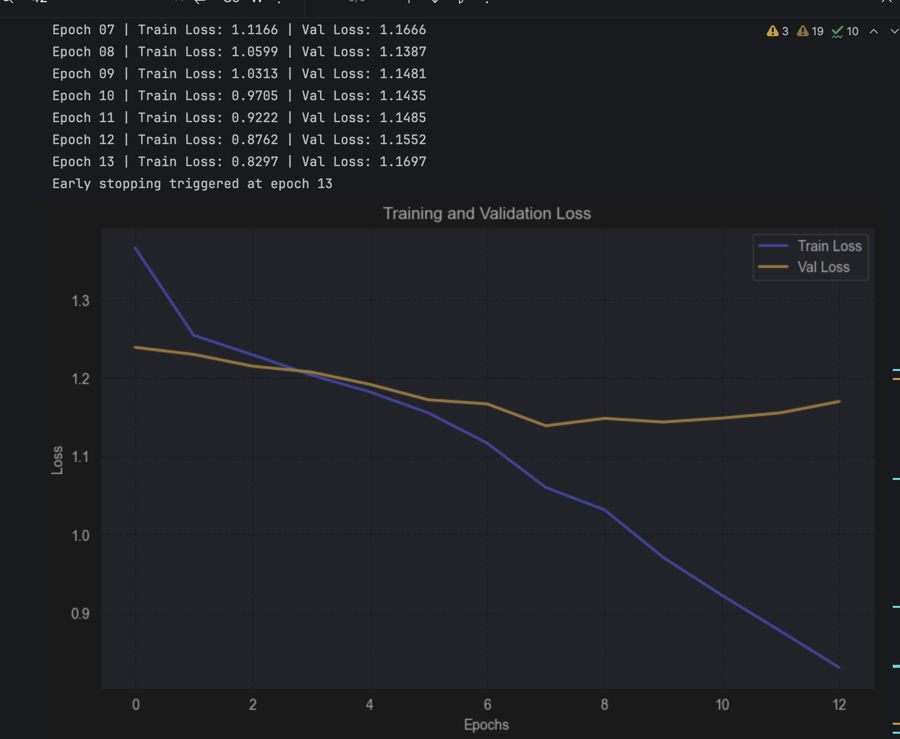

выполнили супер остановку по супер семинарскому методу

вместо RNN LSTM или что угодно - RNN плохо работает с длинными последовательностями

Слишком маленький датасет
Слишком большие последовательности

Можно еще добавить что в данном случае можно было бы также попробовать перейти к варианту где может быть несколько меток на выбор, тогда было бы больше данных для обучения, но эта задача сложнее и РНН все равно плохо работает с длинными последовательностями( у нас было около 250 медиана, где находится большая часть валидных данных, а она плохо обрабатывает больше 30, ну и мы минимально отсекли самые плохие куски данных, что все равно не очень помогло

Хочу отметить, что я считал необходимым отсечь куски данных, где пересекались целевые метки, потому что это привело бы модель к еще большему количеству неверных выборов, следовательно частных случаев, и переобучения

ну а в остальном - data leakage нет, переобучения тоже(early stopping helped + как можно переобучить то что почти не двигает val график, даже несмотря на то что трейн падает), как будто работа над ошибками с прошлой лабы сделана, сейчас час ночи, а можно мы будем считать что 7 февраля заканчивается только когда студент ложится и закрывает глаза?) у меня пока что именно такой случай :)